# Modeling Variance Threshold - Random Forest - Hugo Fiévet

## Table of Contents

1. [Objective](#1-objective)
2. [Baseline Model](#2-baseline-model)
3. [Hyperparameter Tuning](#3-hyperparameter-tuning)
4. [Final Evaluation](#4-final-evaluation)
5. [Model Limits](#5-model-limits)

## 1. Objective


Etablir une performance de référence du modèle avec ses paramètres par défaut avant optimisation des hyperparamètres.

## 2. Baseline Model

In [1]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, cross_validate,GridSearchCV,StratifiedGroupKFold
from sklearn.metrics import  accuracy_score,precision_score,recall_score,f1_score,classification_report,confusion_matrix
RANDOM_STATE = 42

rfc =  RandomForestClassifier(random_state=RANDOM_STATE,n_jobs=-1)

xtrain_VT = pd.read_csv("xtrain_VT.csv")
ytrain = pd.read_csv("ytrain.csv").squeeze("columns")
kepid_train = pd.read_csv("kepid_train.csv").squeeze("columns")

Stratified_G_Kfold_cv = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

cv_results = cross_validate(estimator=rfc,X=xtrain_VT,y=ytrain,groups=kepid_train,scoring="f1_macro",return_train_score=True,cv=Stratified_G_Kfold_cv)
df_results = pd.DataFrame(cv_results)

df_results

,fit_time,score_time,test_score,train_score
0,0.519863,0.037409,0.714142,1.0
1,0.482827,0.038131,0.723588,1.0
2,0.473326,0.037412,0.747023,1.0
3,0.481282,0.037322,0.755650,1.0
4,0.469725,0.036309,0.754896,1.0


In [2]:
print("Mean train score : ",cv_results["train_score"].mean())
print("Mean validation score",cv_results["test_score"].mean())

Mean train score :  1.0
Mean validation score 0.7390598263344456


Le **Random Forest** avec ses hyperparamètres par défaut obtient un **F1-macro moyen** d’environ **0,739** en **validation croisée**. Les **scores de validation varient** d’environ **0,714 à 0,756**, ce qui montre une **performance relativement stable** entre les différents folds.

En revanche, le **F1-macro d’entraînement** est de **1,00** sur **tous les folds**. L’écart important entre les performances d’entraînement et de validation indique que le **modèle** présente un **surapprentissage important** : il s’adapte presque parfaitement aux données d’entraînement mais généralise moins bien sur des étoiles non utilisées pour son entraînement.

Cette **baseline** constitue donc **un point de référence avant optimisation**. Le tuning des hyperparamètres devra chercher à réduire la complexité du Random Forest afin de diminuer l’écart entre les performances d’entraînement et de validation, tout en maintenant ou en améliorant le F1-macro de validation.

In [3]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

## 3. Hyperparameter Tuning

In [4]:


settings_grid= {
    "max_depth":[5, 10, 15, 20],
    "min_samples_leaf":[2, 5, 10],
    "min_samples_split":[2, 5, 10],
    "max_features":["sqrt", 0.5],
}

grid_search = GridSearchCV(estimator=rfc,param_grid=settings_grid,scoring="f1_macro",cv=Stratified_G_Kfold_cv,return_train_score=True)

grid_search.fit(
    xtrain_VT,
    ytrain,
    groups=kepid_train,
)

,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [5, 10, ...], 'max_features': ['sqrt', 0.5], 'min_samples_leaf': [2, 5, ...], 'min_samples_split': [2, 5, ...]}"
,scoring,'f1_macro'
,n_jobs,None
,refit,True
,cv,StratifiedGro... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,n_estimators,100


La seconde recherche d'hyperparamètres, davantage orientée vers la régularisation, sélectionne `max_depth=20`, `min_samples_leaf=2`, `min_samples_split=5` et `max_features=0.5`.

Le **F1-macro moyen** en **validation est de 0,7405**, très proche des **0,7417 obtenus avec la première recherche**. En revanche, le **F1-macro d'entraînement diminue** de **0,9999 à 0,9776**. **L'écart** entre entraînement et validation passe ainsi d'environ **0,258 à 0,237**.

La **régularisation réduit** donc **légèrement le surapprentissage** sans dégrader significativement les performances de validation. Le **modèle présente néanmoins encore un surapprentissage important**.

Je **retiens la configuration** issue du **second GridSearch**, **car** elle est **moins complexe** et **généralise pratiquement** aussi **bien** que la configuration non contrainte.

In [5]:
best_i = grid_search.best_index_

print("Best parameters:", grid_search.best_params_)
print("Best validation F1:", grid_search.best_score_)
print(
    "Mean train F1:",
    grid_search.cv_results_["mean_train_score"][best_i]
)
print(
    "Std validation F1:",
    grid_search.cv_results_["std_test_score"][best_i]
)

Best parameters: {'max_depth': 20, 'max_features': 0.5, 'min_samples_leaf': 2, 'min_samples_split': 5}
Best validation F1: 0.7404916658490465
Mean train F1: 0.9776184684516076
Std validation F1: 0.01420768203898487


## 4. Final Evaluation

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt
X_test_VT = pd.read_csv("xtest_VT.csv")
y_test = pd.read_csv("ytest.csv").squeeze("columns")

best_model = grid_search.best_estimator_

y_pred = best_model.predict(X=X_test_VT)

class_report = classification_report(y_test, y_pred)
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="macro")
recall = recall_score(y_test, y_pred, average="macro")
f1 = f1_score(y_test, y_pred, average="macro")

print("Accuracy :",accuracy )
print("Precision macro :",precision )
print("Recall macro :",recall )
print("F1 macro :", f1)

Accuracy : 0.7860147213459516
Precision macro : 0.7588477745508073
Recall macro : 0.7543465511902233
F1 macro : 0.753430924304164


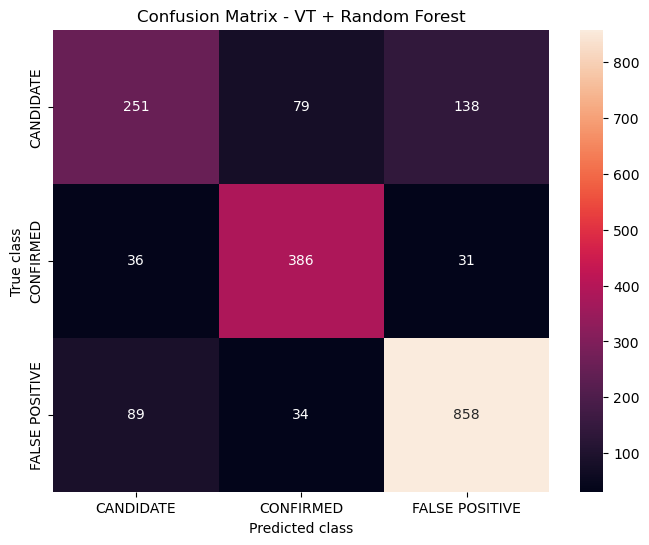

In [7]:
labels = ["CANDIDATE", "CONFIRMED", "FALSE POSITIVE"]

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=labels
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=labels,
    yticklabels=labels,
)

plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.title("Confusion Matrix - VT + Random Forest")

plt.show();

Le Random Forest utilisant la sélection Variance Threshold fournit les meilleurs résultats parmi ces trois combinaisons.

Sur les 468 CANDIDATE, 258 sont correctement identifiés, contre 83 prédits CONFIRMED et 127 FALSE POSITIVE. Parmi les 453 CONFIRMED, 384 sont correctement classés, et parmi les 981 FALSE POSITIVE, 844 sont correctement reconnus.

La classe CANDIDATE reste la plus difficile à distinguer, mais ce modèle réduit les erreurs par rapport aux deux autres combinaisons. Il obtient également de meilleures performances pour les classes CONFIRMED et FALSE POSITIVE

## 5. Model Limits

Cette combinaison obtient les meilleurs résultats des trois sur chacune des classes. Cela suggère que le maintien d’un ensemble relativement large de variables après Variance Threshold est bénéfique au Random Forest, qui peut exploiter des interactions entre plusieurs caractéristiques sans dépendre d’un seul arbre. Toutefois, la classe CANDIDATE reste la plus difficile à prédire, ce qui suggère qu’une partie de l’erreur pourrait provenir de l’ambiguïté intrinsèque de cette classe plutôt que d’un simple manque de capacité du modèle